In [1]:
import pandas as pd

df = pd.read_csv("../dataset/waste_data.csv")

print("Dataset loaded successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Dataset loaded successfully!
Rows: 9125
Columns: 8


In [2]:
df.head()

,Date,Area,Waste_Type,Waste_Collected_kg,Population,Collection_Vehicles,Temperature_C,Rainfall_mm
0,2025-01-01,Vidyanagar,Organic,11.88,25000,1,20.4,8.3
1,2025-01-01,Vidyanagar,Plastic,4.00,25000,1,31.0,20.3
2,2025-01-01,Vidyanagar,Paper,3.47,25000,1,21.3,12.7
3,2025-01-01,Vidyanagar,Glass,1.42,25000,1,23.3,15.2
4,2025-01-01,Vidyanagar,Metal,1.01,25000,1,23.0,19.5


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9125 entries, 0 to 9124
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 9125 non-null   object 
 1   Area                 9125 non-null   object 
 2   Waste_Type           9125 non-null   object 
 3   Waste_Collected_kg   9125 non-null   float64
 4   Population           9125 non-null   int64  
 5   Collection_Vehicles  9125 non-null   int64  
 6   Temperature_C        9125 non-null   float64
 7   Rainfall_mm          9125 non-null   float64
dtypes: float64(3), int64(2), object(3)
memory usage: 570.4+ KB


In [4]:
df.describe()

,Waste_Collected_kg,Population,Collection_Vehicles,Temperature_C,Rainfall_mm
count,9125.000000,9125.000000,9125.0,9125.000000,9125.000000
mean,5.404615,31000.000000,1.0,27.444964,14.955003
std,5.111130,9879.812603,0.0,4.326217,8.664978
min,0.880000,22000.000000,1.0,20.000000,0.000000
25%,1.870000,25000.000000,1.0,23.700000,7.400000
50%,3.450000,28000.000000,1.0,27.400000,15.100000
75%,6.660000,30000.000000,1.0,31.200000,22.400000
max,26.990000,50000.000000,1.0,35.000000,30.000000


In [5]:
# Convert Date column to datetime format
df["Date"] = pd.to_datetime(df["Date"])

# Check the data types
df.dtypes

Date                   datetime64[ns]
Area                           object
Waste_Type                     object
Waste_Collected_kg            float64
Population                      int64
Collection_Vehicles             int64
Temperature_C                 float64
Rainfall_mm                   float64
dtype: object

In [6]:
# Check for missing values
df.isnull().sum()

Date                   0
Area                   0
Waste_Type             0
Waste_Collected_kg     0
Population             0
Collection_Vehicles    0
Temperature_C          0
Rainfall_mm            0
dtype: int64

In [7]:
# Calculate total waste generated
total_waste = df["Waste_Collected_kg"].sum()

print("Total waste generated:", round(total_waste, 2), "kg")

Total waste generated: 49317.11 kg


In [8]:
# Calculate average daily waste
daily_waste = df.groupby("Date")["Waste_Collected_kg"].sum()

print("Average daily waste:", round(daily_waste.mean(), 2), "kg")

Average daily waste: 135.12 kg


In [9]:
# Find the day with maximum waste generation
max_day = daily_waste.idxmax()
max_waste = daily_waste.max()

print("Highest waste generation date:", max_day.date())
print("Waste generated on that day:", round(max_waste, 2), "kg")

Highest waste generation date: 2025-10-03
Waste generated on that day: 147.12 kg


In [10]:
# Calculate total waste generated by each area
area_waste = df.groupby("Area")["Waste_Collected_kg"].sum().sort_values(ascending=False)

print("Total waste generated by each area:")
print(area_waste)

Total waste generated by each area:
Area
Hubli         15964.96
Dharwad        9510.04
Keshwapur      8919.37
Vidyanagar     7943.65
Gokul Road     6979.09
Name: Waste_Collected_kg, dtype: float64


In [11]:
# Find the area with the highest waste generation
highest_area = area_waste.idxmax()
highest_area_waste = area_waste.max()

print("Area with highest waste generation:", highest_area)
print("Total waste generated:", round(highest_area_waste, 2), "kg")

Area with highest waste generation: Hubli
Total waste generated: 15964.96 kg


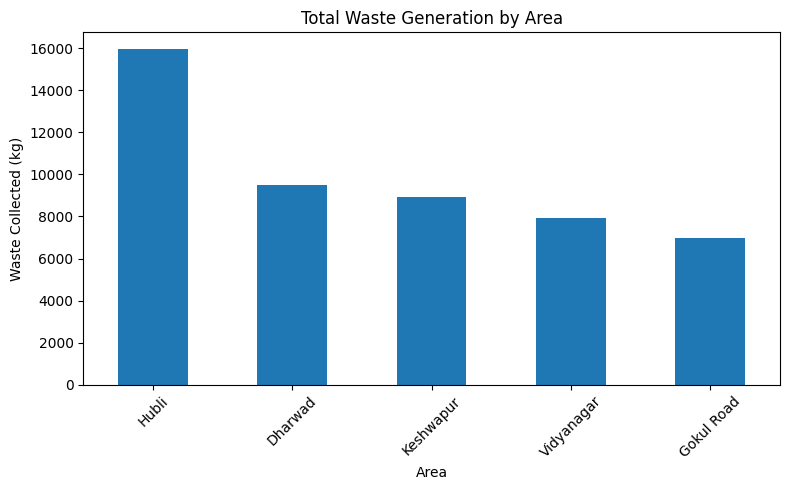

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

area_waste.plot(kind="bar")

plt.title("Total Waste Generation by Area")
plt.xlabel("Area")
plt.ylabel("Waste Collected (kg)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


In [13]:
# Calculate total waste generated by each waste type
waste_type_total = (
    df.groupby("Waste_Type")["Waste_Collected_kg"]
    .sum()
    .sort_values(ascending=False)
)

print("Total waste generated by each waste type:")
print(waste_type_total)

Total waste generated by each waste type:
Waste_Type
Organic    25491.49
Plastic    10218.58
Paper       6797.21
Glass       3976.02
Metal       2833.81
Name: Waste_Collected_kg, dtype: float64


In [14]:
# Find the waste type with the highest generation
highest_waste_type = waste_type_total.idxmax()
highest_waste_amount = waste_type_total.max()

print("Most generated waste type:", highest_waste_type)
print("Total amount:", round(highest_waste_amount, 2), "kg")

Most generated waste type: Organic
Total amount: 25491.49 kg


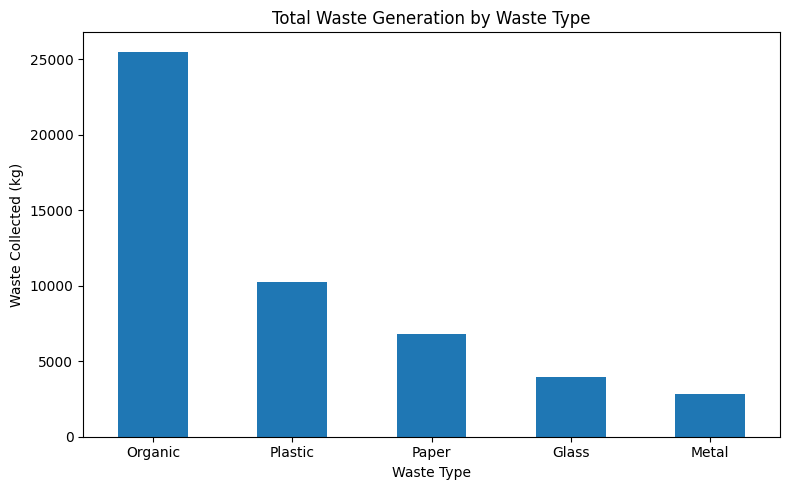

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

waste_type_total.plot(kind="bar")

plt.title("Total Waste Generation by Waste Type")
plt.xlabel("Waste Type")
plt.ylabel("Waste Collected (kg)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [16]:
# Create a Month column from the Date
df["Month"] = df["Date"].dt.to_period("M")

# Check the result
df[["Date", "Month"]].head()

,Date,Month
0,2025-01-01,2025-01
1,2025-01-01,2025-01
2,2025-01-01,2025-01
3,2025-01-01,2025-01
4,2025-01-01,2025-01


In [17]:
# Calculate total waste generated each month
monthly_waste = (
    df.groupby("Month")["Waste_Collected_kg"]
    .sum()
)

print("Monthly Waste Generation:")
print(monthly_waste)

Monthly Waste Generation:
Month
2025-01    4239.30
2025-02    3780.96
2025-03    4227.52
2025-04    4063.01
2025-05    4197.33
2025-06    4049.10
2025-07    4163.46
2025-08    4177.90
2025-09    4062.36
2025-10    4155.48
2025-11    4010.92
2025-12    4189.77
Freq: M, Name: Waste_Collected_kg, dtype: float64


In [18]:
# Calculate waste generated by each area and waste type
area_type_waste = df.pivot_table(
    values="Waste_Collected_kg",
    index="Area",
    columns="Waste_Type",
    aggfunc="sum"
)

area_type_waste

Waste_Type,Glass,Metal,Organic,Paper,Plastic
Area,,,,,
Dharwad,765.84,546.37,4910.43,1312.85,1974.55
Gokul Road,568.15,400.87,3598.00,961.00,1451.07
Hubli,1283.99,913.59,8253.87,2197.61,3315.90
Keshwapur,718.10,517.30,4613.73,1234.10,1836.14
Vidyanagar,639.94,455.68,4115.46,1091.65,1640.92


In [19]:
# Round the values for easier reading
area_type_waste.round(2)

Waste_Type,Glass,Metal,Organic,Paper,Plastic
Area,,,,,
Dharwad,765.84,546.37,4910.43,1312.85,1974.55
Gokul Road,568.15,400.87,3598.00,961.00,1451.07
Hubli,1283.99,913.59,8253.87,2197.61,3315.90
Keshwapur,718.10,517.30,4613.73,1234.10,1836.14
Vidyanagar,639.94,455.68,4115.46,1091.65,1640.92


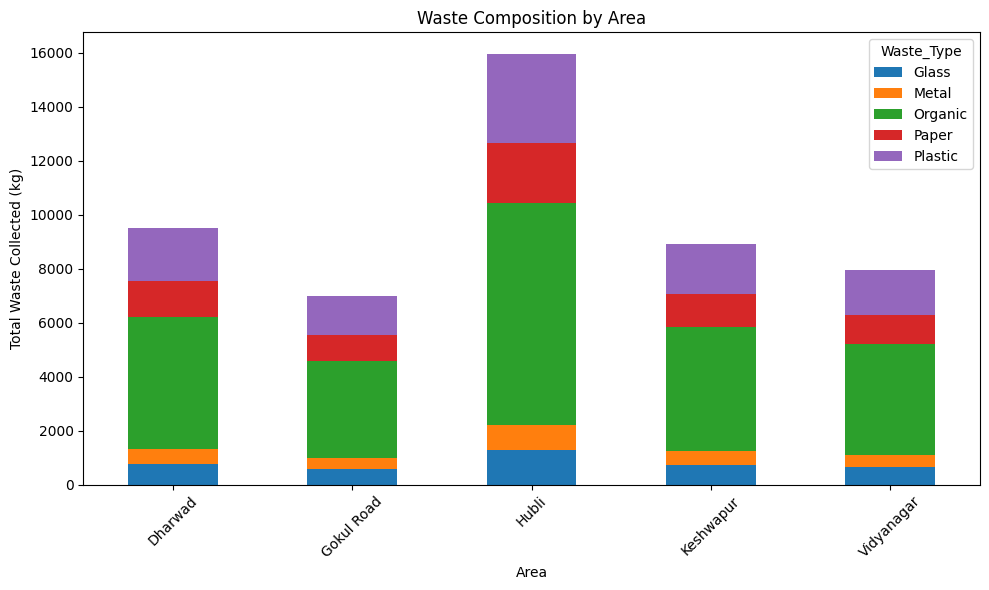

In [20]:
import matplotlib.pyplot as plt

area_type_waste.plot(
    kind="bar",
    figsize=(10, 6),
    stacked=True
)

plt.title("Waste Composition by Area")
plt.xlabel("Area")
plt.ylabel("Total Waste Collected (kg)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [21]:
# Check correlation between weather and waste generation

correlation = df[
    ["Waste_Collected_kg", "Temperature_C", "Rainfall_mm"]
].corr()

correlation.round(2)

,Waste_Collected_kg,Temperature_C,Rainfall_mm
Waste_Collected_kg,1.00,0.01,0.01
Temperature_C,0.01,1.00,-0.01
Rainfall_mm,0.01,-0.01,1.00


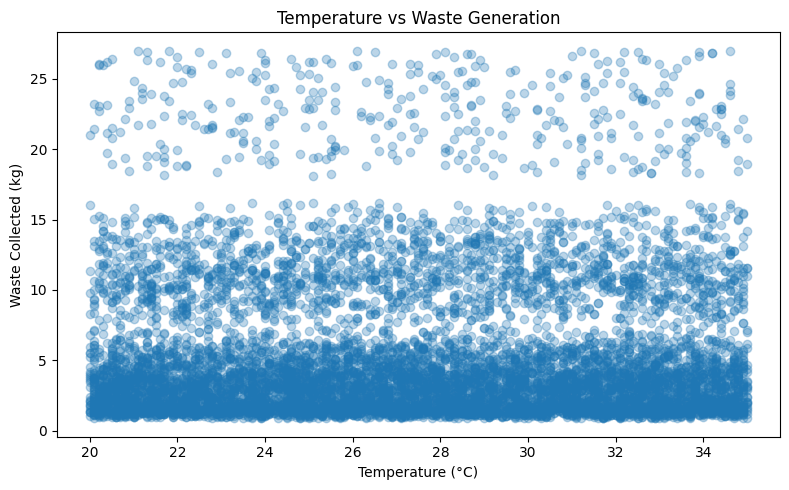

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Temperature_C"],
    df["Waste_Collected_kg"],
    alpha=0.3
)

plt.title("Temperature vs Waste Generation")
plt.xlabel("Temperature (°C)")
plt.ylabel("Waste Collected (kg)")

plt.tight_layout()
plt.show()

In [24]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [25]:
# Convert categorical columns into numerical columns
model_data = pd.get_dummies(
    df,
    columns=["Area", "Waste_Type"],
    drop_first=True
)

model_data.head()

,Date,Waste_Collected_kg,Population,Collection_Vehicles,Temperature_C,Rainfall_mm,Month,Area_Gokul Road,Area_Hubli,Area_Keshwapur,Area_Vidyanagar,Waste_Type_Metal,Waste_Type_Organic,Waste_Type_Paper,Waste_Type_Plastic
0,2025-01-01,11.88,25000,1,20.4,8.3,2025-01,False,False,False,True,False,True,False,False
1,2025-01-01,4.00,25000,1,31.0,20.3,2025-01,False,False,False,True,False,False,False,True
2,2025-01-01,3.47,25000,1,21.3,12.7,2025-01,False,False,False,True,False,False,True,False
3,2025-01-01,1.42,25000,1,23.3,15.2,2025-01,False,False,False,True,False,False,False,False
4,2025-01-01,1.01,25000,1,23.0,19.5,2025-01,False,False,False,True,True,False,False,False


In [26]:
# Input features
X = model_data.drop(columns=["Date", "Month", "Waste_Collected_kg"])

# Target variable
y = model_data["Waste_Collected_kg"]

print("Input features:", X.shape)
print("Target values:", y.shape)

Input features: (9125, 12)
Target values: (9125,)


In [27]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 7300
Testing records: 1825


In [28]:
# Create and train the Linear Regression model
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [29]:
# Predict waste for the test data
y_pred = model.predict(X_test)

print("Predictions created successfully!")
print(y_pred[:10])

Predictions created successfully!
[ 3.49190752  4.93654324  1.93534554  2.10214682  3.2405405   1.10685201
  8.9713141  17.3129748   0.57045118  0.58688187]


In [30]:
# Evaluate model performance
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", round(mae, 2))
print("R² Score:", round(r2, 2))

Mean Absolute Error: 1.05
R² Score: 0.89


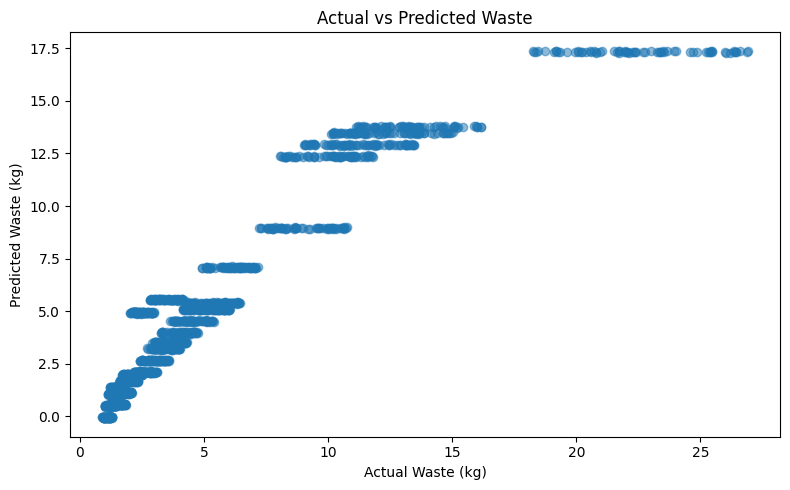

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.title("Actual vs Predicted Waste")
plt.xlabel("Actual Waste (kg)")
plt.ylabel("Predicted Waste (kg)")

plt.tight_layout()
plt.show()

In [32]:
import joblib

joblib.dump(model, "../src/waste_prediction_model.pkl")

print("Model saved successfully!")

Model saved successfully!
